# Zadanie 14: Analiza cukrzycy (dataset z folderu `cukrzyca`)

> Ten notatnik to kompletne rozwiązanie ćwiczenia dla danych o cukrzycy. Każdy krok jest opisany prostym językiem: **co robimy, po co to robimy i co oznaczają parametry**.

## 0. Środowisko
W tej części ładujemy biblioteki.

Krótko o bibliotekach:
- `pandas` i `numpy`: tabele i obliczenia.
- `matplotlib` i `seaborn`: wykresy.
- `scikit-learn`: podział danych, skalowanie i model klasyfikacji.

Jeśli brakuje bibliotek, odkomentuj poniższą linię w komórce kodu:
`# !pip install pandas numpy matplotlib seaborn scikit-learn`

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import glob
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (9, 5)

print('Biblioteki załadowane.')

Biblioteki załadowane.


## 1. Import danych z folderu `cukrzyca`
Wczytujemy **wszystkie pliki `data-*`** i łączymy je w jedną tabelę.

Co ważne:
- `glob.glob('cukrzyca/data-*')` znajduje wszystkie pliki pasujące do wzorca.
- Dla każdego wiersza zapisujemy też nazwę pliku (`patient_file`) jako identyfikator pacjenta.
- Dane są rozdzielone tabulatorem, więc dzielimy linię po `\t`.

In [2]:
def load_diabetes_folder(folder_path='cukrzyca'):
    """Wczytuje wszystkie pliki data-* do jednej ramki danych."""
    rows = []
    file_paths = sorted(glob.glob(os.path.join(folder_path, 'data-*')))

    for path in file_paths:
        patient_file = os.path.basename(path)
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.rstrip('\n').split('\t')

                # Oczekujemy 4 pól: data, czas, kod zdarzenia, wartość
                if len(parts) < 4:
                    continue

                date_raw, time_raw, code_raw, value_raw = parts[0], parts[1], parts[2], parts[3]
                rows.append([patient_file, date_raw, time_raw, code_raw, value_raw])

    df_raw = pd.DataFrame(rows, columns=['patient_file', 'date_raw', 'time_raw', 'code_raw', 'value_raw'])
    return df_raw

df_raw = load_diabetes_folder('cukrzyca')

print('Liczba wszystkich surowych rekordów:', len(df_raw))
display(df_raw.head(10))

Liczba wszystkich surowych rekordów: 29330


,patient_file,date_raw,time_raw,code_raw,value_raw
0,data-01,04-21-1991,9:09,58,100
1,data-01,04-21-1991,9:09,33,009
2,data-01,04-21-1991,9:09,34,013
3,data-01,04-21-1991,17:08,62,119
4,data-01,04-21-1991,17:08,33,007
5,data-01,04-21-1991,22:51,48,123
6,data-01,04-22-1991,7:35,58,216
7,data-01,04-22-1991,7:35,33,010
8,data-01,04-22-1991,7:35,34,013
9,data-01,04-22-1991,13:40,33,002


## 2. Wstępne przetwarzanie danych (czyszczenie + przygotowanie cech)
Tu robimy porządek w danych.

Najważniejsze decyzje i ich wpływ:
- `errors='coerce'` przy konwersji: błędne wartości zamieniają się na `NaN` zamiast psuć cały program.
- Zamiana `0Hi` i `0Lo` na liczby: dzięki temu model może je przetwarzać.
- `dropna(...)`: usuwamy rekordy, których i tak nie da się wiarygodnie użyć.
- `code.between(33, 72)`: zostawiamy tylko sensowne kody zdarzeń z tego zbioru.

In [3]:
df = df_raw.copy()

# 1) Nietypowe zapisy wartości glikemii zamieniamy na liczby/graniczne przybliżenia
special_values_map = {
    '0Hi': '400',  # bardzo wysoka glukoza (przybliżenie)
    '0Lo': '40',   # bardzo niska glukoza (przybliżenie)
    "0''": np.nan
}
df['value_raw'] = df['value_raw'].replace(special_values_map)

# 2) Tworzymy pełny znacznik czasu
df['datetime'] = pd.to_datetime(
    df['date_raw'].astype(str).str.strip() + ' ' + df['time_raw'].astype(str).str.strip(),
    format='%m-%d-%Y %H:%M',
    errors='coerce'
 )

# 3) Zamieniamy kod i wartość na liczby
df['code'] = pd.to_numeric(df['code_raw'], errors='coerce')
df['value'] = pd.to_numeric(df['value_raw'], errors='coerce')

before_drop = len(df)
df = df.dropna(subset=['datetime', 'code', 'value']).copy()
df['code'] = df['code'].astype(int)
df = df[df['code'].between(33, 72)].copy()
after_drop = len(df)

print(f'Rekordy przed czyszczeniem: {before_drop}')
print(f'Rekordy po czyszczeniu:    {after_drop}')
print(f'Usunięte rekordy:          {before_drop - after_drop}')

display(df.head(10))

print('\nPodstawowe informacje o tabeli po czyszczeniu:')
display(df[['patient_file', 'datetime', 'code', 'value']].info())

Rekordy przed czyszczeniem: 29330
Rekordy po czyszczeniu:    29250
Usunięte rekordy:          80


,patient_file,date_raw,time_raw,code_raw,value_raw,datetime,code,value
0,data-01,04-21-1991,9:09,58,100,1991-04-21 09:09:00,58,100.0
1,data-01,04-21-1991,9:09,33,009,1991-04-21 09:09:00,33,9.0
2,data-01,04-21-1991,9:09,34,013,1991-04-21 09:09:00,34,13.0
3,data-01,04-21-1991,17:08,62,119,1991-04-21 17:08:00,62,119.0
4,data-01,04-21-1991,17:08,33,007,1991-04-21 17:08:00,33,7.0
5,data-01,04-21-1991,22:51,48,123,1991-04-21 22:51:00,48,123.0
6,data-01,04-22-1991,7:35,58,216,1991-04-22 07:35:00,58,216.0
7,data-01,04-22-1991,7:35,33,010,1991-04-22 07:35:00,33,10.0
8,data-01,04-22-1991,7:35,34,013,1991-04-22 07:35:00,34,13.0
9,data-01,04-22-1991,13:40,33,002,1991-04-22 13:40:00,33,2.0



Podstawowe informacje o tabeli po czyszczeniu:
<class 'pandas.core.frame.DataFrame'>
Index: 29250 entries, 0 to 29329
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_file  29250 non-null  object        
 1   datetime      29250 non-null  datetime64[ns]
 2   code          29250 non-null  int64         
 3   value         29250 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.1+ MB


None

## 3. Analiza i wizualizacja
Skupiamy się na pomiarach glikemii i ich zależnościach.

Co oznacza wybrane kryterium:
- Za hiperglikemię przyjmujemy `glukoza >= 180 mg/dL`.
- To będzie też później nasza zmienna docelowa (`target_hyper`).

Liczba pomiarów glukozy: 13525
Udział hiperglikemii (>=180 mg/dL): 0.365

Statystyki glikemii (value):


count    13525.000000
mean       160.343882
std         80.314133
min          0.000000
25%         97.000000
50%        149.000000
75%        210.000000
max        501.000000
Name: value, dtype: float64


Najczęstsze kody pomiarów:


code
48    1883
57     989
58    3516
59      20
60    2770
61      66
62    3158
63     219
64     904
Name: count, dtype: int64

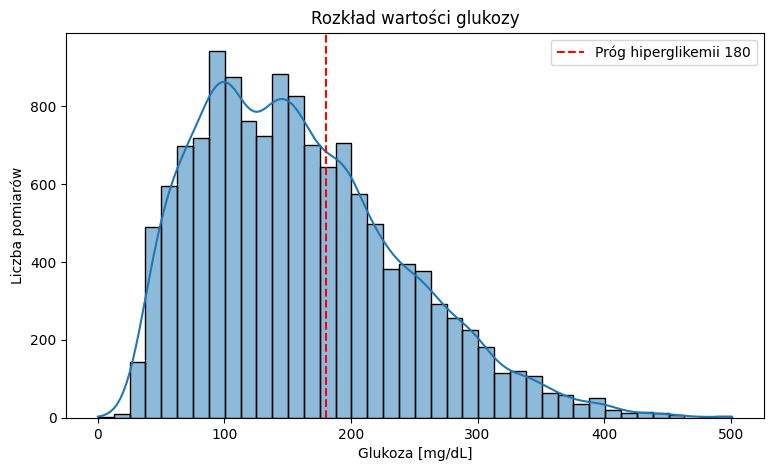

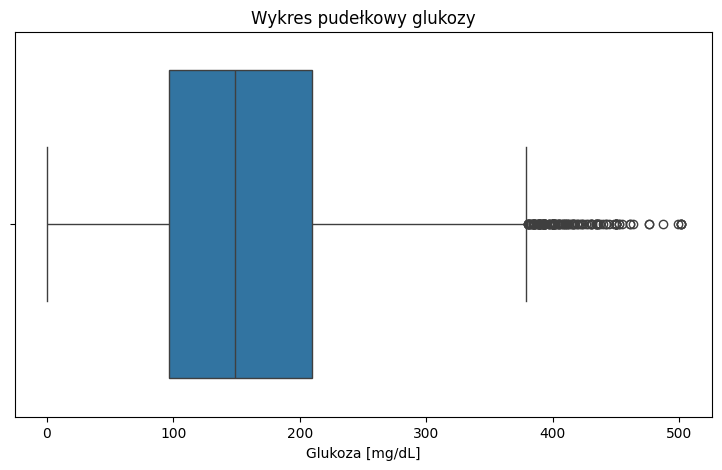

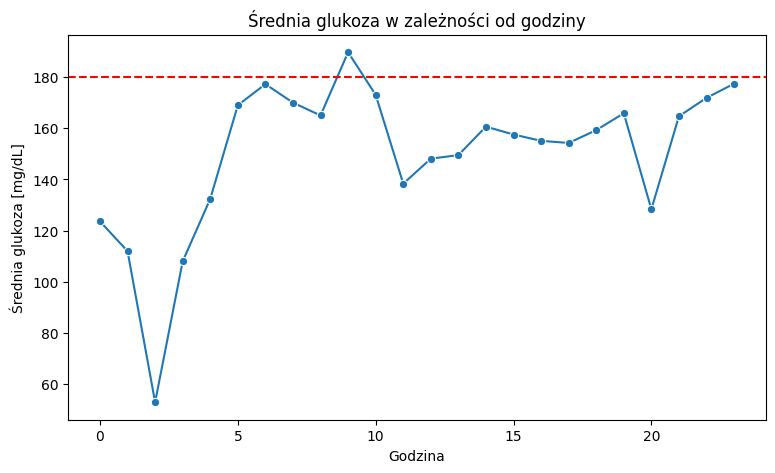

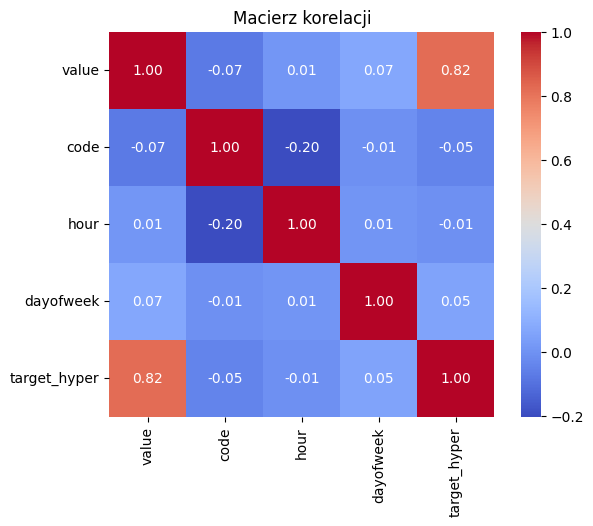

In [4]:
bg_codes = {48, 57, 58, 59, 60, 61, 62, 63, 64}
bg = df[df['code'].isin(bg_codes)].copy()

# Cechy czasowe
bg['hour'] = bg['datetime'].dt.hour
bg['dayofweek'] = bg['datetime'].dt.dayofweek
bg['target_hyper'] = (bg['value'] >= 180).astype(int)

print('Liczba pomiarów glukozy:', len(bg))
print('Udział hiperglikemii (>=180 mg/dL):', round(bg['target_hyper'].mean(), 3))

print('\nStatystyki glikemii (value):')
display(bg['value'].describe())

print('\nNajczęstsze kody pomiarów:')
display(bg['code'].value_counts().sort_index())

# 1) Histogram glukozy
plt.figure()
sns.histplot(bg['value'], bins=40, kde=True)
plt.axvline(180, color='red', linestyle='--', label='Próg hiperglikemii 180')
plt.title('Rozkład wartości glukozy')
plt.xlabel('Glukoza [mg/dL]')
plt.ylabel('Liczba pomiarów')
plt.legend()
plt.show()

# 2) Boxplot glukozy
plt.figure()
sns.boxplot(x=bg['value'])
plt.title('Wykres pudełkowy glukozy')
plt.xlabel('Glukoza [mg/dL]')
plt.show()

# 3) Średnia glukoza w godzinach doby
hour_profile = bg.groupby('hour', as_index=False)['value'].mean()
plt.figure()
sns.lineplot(data=hour_profile, x='hour', y='value', marker='o')
plt.axhline(180, color='red', linestyle='--')
plt.title('Średnia glukoza w zależności od godziny')
plt.xlabel('Godzina')
plt.ylabel('Średnia glukoza [mg/dL]')
plt.show()

# 4) Korelacja cech liczbowych
corr_df = bg[['value', 'code', 'hour', 'dayofweek', 'target_hyper']].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Macierz korelacji')
plt.show()

## 4. Przygotowanie do modelowania i model klasyfikacyjny
Budujemy prosty model: regresja logistyczna.

Co przewidujemy:
- `target_hyper = 1` gdy glukoza >= 180, w przeciwnym razie 0.

Dlaczego porównujemy 2 metody skalowania:
- `StandardScaler`: przekształca cechy tak, by miały średnią około 0 i odchylenie standardowe 1.
- `MinMaxScaler`: wciska cechy do zakresu 0..1.
- Obie metody mogą wpływać na jakość klasyfikacji i stabilność modelu.

,Metoda,Accuracy,ROC_AUC
1,MinMaxScaler,0.620690,0.699865
0,StandardScaler,0.620987,0.699725


Najlepsza metoda skalowania wg ROC_AUC: MinMaxScaler

Raport klasyfikacji (najlepszy model):
              precision    recall  f1-score   support

           0      0.759     0.591     0.664      2137
           1      0.486     0.673     0.564      1227

    accuracy                          0.621      3364
   macro avg      0.622     0.632     0.614      3364
weighted avg      0.659     0.621     0.628      3364



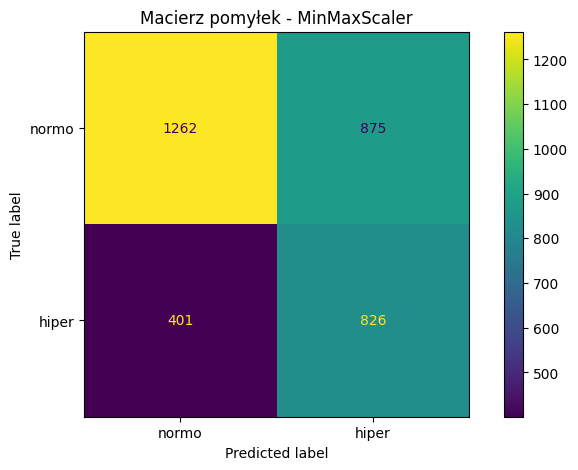

In [5]:
# Tworzymy cechę "poprzedni pomiar glukozy" dla każdego pacjenta
bg = bg.sort_values(['patient_file', 'datetime']).copy()
bg['prev_glucose'] = bg.groupby('patient_file')['value'].shift(1)

model_df = bg.dropna(subset=['prev_glucose']).copy()

X = model_df[['patient_file', 'code', 'hour', 'dayofweek', 'prev_glucose']]
y = model_df['target_hyper']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
 )

num_features = ['code', 'hour', 'dayofweek', 'prev_glucose']
cat_features = ['patient_file']

def build_pipeline(scaler):
    """Tworzy pipeline z wybraną metodą skalowania."""
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_features),
            ('cat', categorical_transformer, cat_features),
        ],
        remainder='drop'
    )

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    return clf

models = {
    'StandardScaler': build_pipeline(StandardScaler()),
    'MinMaxScaler': build_pipeline(MinMaxScaler())
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append({'Metoda': name, 'Accuracy': acc, 'ROC_AUC': roc})
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False)
display(results_df)

best_name = results_df.iloc[0]['Metoda']
best_model = fitted_models[best_name]

print(f'Najlepsza metoda skalowania wg ROC_AUC: {best_name}')

y_pred_best = best_model.predict(X_test)
print('\nRaport klasyfikacji (najlepszy model):')
print(classification_report(y_test, y_pred_best, digits=3))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['normo', 'hiper'])
disp.plot(values_format='d')
plt.title(f'Macierz pomyłek - {best_name}')
plt.show()

## 5. Podsumowanie "jak dziecku"
1. Najpierw zebraliśmy wszystkie kartki (pliki) do jednego zeszytu (DataFrame).
2. Potem poprawiliśmy literówki i dziwne wpisy, żeby komputer się nie mylił.
3. Narysowaliśmy wykresy, żeby zobaczyć, co dzieje się z cukrem we krwi.
4. Na końcu nauczyliśmy prosty model odróżniać: "hiperglikemia" vs "brak hiperglikemii".

Co można zrobić inaczej i jaki to ma wpływ:
- Inny próg klasy (`160` lub `200` zamiast `180`) zmieni liczbę przypadków pozytywnych.
- Inny model (np. `RandomForestClassifier`) może lepiej łapać nieliniowe zależności.
- Lepsze cechy czasowe (np. trend z 3 ostatnich pomiarów) często poprawiają jakość predykcji.
- Inna metoda podziału danych (np. podział po pacjentach) daje bardziej realistyczny test jakości.